In [1]:
#Research Question: Can we use ARIMA to forecast revenue in the future?

In [2]:
#Standard Analysis imports:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Importing Data:
df = pd.read_csv('C:\\Users\\weepo\\Documents\\WGU\\D213\\Task 1\\Raw Files\\teleco_time_series .csv')

In [4]:
#testing
df.head()

,Day,Revenue
0,1,0.000000
1,2,0.000793
2,3,0.825542
3,4,0.320332
4,5,1.082554


In [5]:
df.shape

(731, 2)

In [6]:
#Checking nulls
df.isna().any()

Day        False
Revenue    False
dtype: bool

In [7]:
#creating indexed dataset
indexedDataset = df.set_index('Day')['Revenue']

Day
1            NaN
2            NaN
3            NaN
4            NaN
5            NaN
         ...    
727    16.687762
728    16.747709
729    16.797078
730    16.820856
731    16.872285
Name: Revenue, Length: 731, dtype: float64 Day
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
         ...   
727    0.918642
728    0.910077
729    0.869363
730    0.841447
731    0.775838
Name: Revenue, Length: 731, dtype: float64


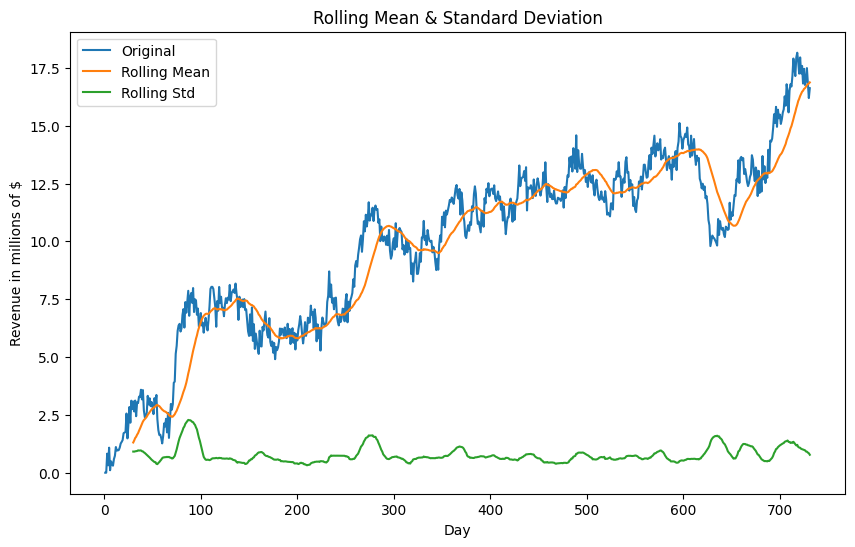

In [8]:
#Got the following code from Dr. Sewell's webinar
rolmean = indexedDataset.rolling(window=30).mean() #Monthly level
rolstd = indexedDataset.rolling(window=30).std()
print(rolmean, rolstd)

plt.figure(figsize=(10, 6))  #Resizing

orig = plt.plot(indexedDataset, label='Original')
mean = plt.plot(rolmean, label='Rolling Mean')
std = plt.plot(rolstd, label='Rolling Std')

plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.xlabel('Day')
plt.ylabel('Revenue in millions of $')
plt.show()

In [9]:
#Revenue is in millions of dollars, window is set to monthly (30 days)
#Checking for stationarity, code is from Dr. Sewell again
from statsmodels.tsa.stattools import adfuller

print('Results of Augmented Dickey-Fuller Test:')

adf_test = adfuller(indexedDataset, autolag='AIC')

df_output = pd.Series(adf_test[0:4], index=['Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used'])

for key, value in adf_test[4].items():
    df_output[f'Critical Value ({key})'] = value

print(df_output)

Results of Augmented Dickey-Fuller Test:
Test Statistic                  -1.924612
p-value                          0.320573
# Lags Used                      1.000000
Number of Observations Used    729.000000
Critical Value (1%)             -3.439352
Critical Value (5%)             -2.865513
Critical Value (10%)            -2.568886
dtype: float64


In [10]:
#p-value is higher than 0.05, and is thus not stationary.

In [11]:
#Splitting data into test and train sets, with training size at 80%
train_size = int(len(indexedDataset) * 0.8)

train = indexedDataset.iloc[:train_size]
test = indexedDataset.iloc[train_size:]

print(f"Training size: {len(train)} observations")
print(f"Testing size: {len(test)} observations")

Training size: 584 observations
Testing size: 147 observations


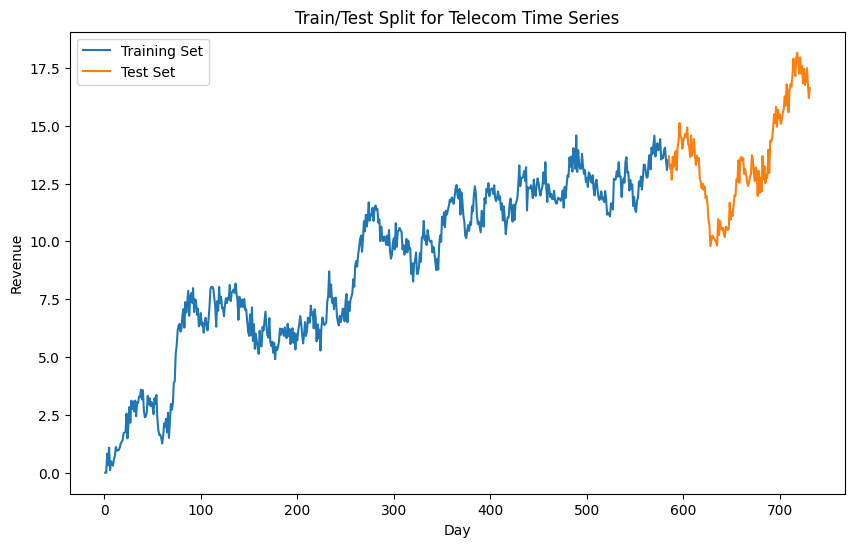

In [12]:
#Visual representation of split
plt.figure(figsize=(10, 6))
plt.plot(train, label='Training Set')
plt.plot(test, label='Test Set')
plt.title('Train/Test Split for Telecom Time Series')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.legend()
plt.show()

In [13]:
#Saving data to csv
train.to_csv('C:\\Users\\weepo\\Documents\\WGU\\D213\\Task 1\\d213task1TRAINdata.csv')
test.to_csv('C:\\Users\\weepo\\Documents\\WGU\\D213\\Task 1\\d213task1TESTdata.csv')

In [14]:
#Seasonality - just by visual inspection nothing stands out, so math it is.
#Code from Dr. Sewell
from pmdarima import auto_arima
stepwise_fit=auto_arima(df['Revenue'],trace=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=987.305, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1162.819, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=983.122, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1019.369, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1162.139, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=985.104, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=985.106, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=986.045, Time=0.43 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=984.710, Time=0.03 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 1.330 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  731
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -488.561
Date:                Fri, 14 Nov 2025   AIC                            983.122
Time:                        08:29:32   BIC                            996.901
Sample:                             0   HQIC                           988.438
                                - 731                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0332      0.018      1.895      0.058      -0.001       0.068
ar.L1         -0.4692      0.033    -14.296      0.000      -0.534      -0.405
sigma2         0.2232      0.013     17.801      0.000       0.199       0.248
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.05
Prob(Q):                              0.96   Prob(JB):                         0.36
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.85   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [15]:
#Important info: Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
#The first set of numbers is p,d,q.
#The second set means no seasonality.
#The third number means no differencing is required for the seasonality.

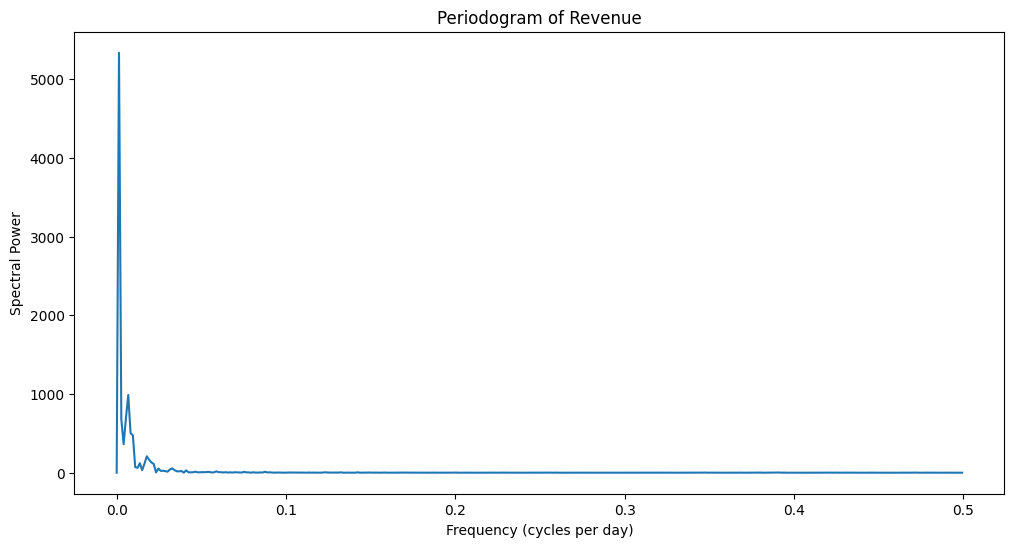

In [16]:
#Visualizing no seasonality using a periodogram
#Code help: https://docs.scipy.org/doc//scipy-1.16.2/reference/generated/scipy.signal.periodogram.html
from scipy.signal import periodogram
import matplotlib.pyplot as plt
import numpy as np

y = df['Revenue'].dropna().values

freqs, power = periodogram(y, fs=1)

plt.figure(figsize=(12, 6))
plt.plot(freqs, power)
plt.title("Periodogram of Revenue")
plt.xlabel("Frequency (cycles per day)")
plt.ylabel("Spectral Power")
plt.show()

In [17]:
#Graph demonstrates no seasonality
#After intial spike at 0, there are rapidly shrinking peaks then no peaks.

#Trends: The time series exhibits a clear long-term upward trend, 
#with revenue increasing steadily over the two-year period. The rolling mean shows a smooth rising pattern, 
#indicating sustained growth rather than temporary spikes.

<Figure size 1200x600 with 0 Axes>

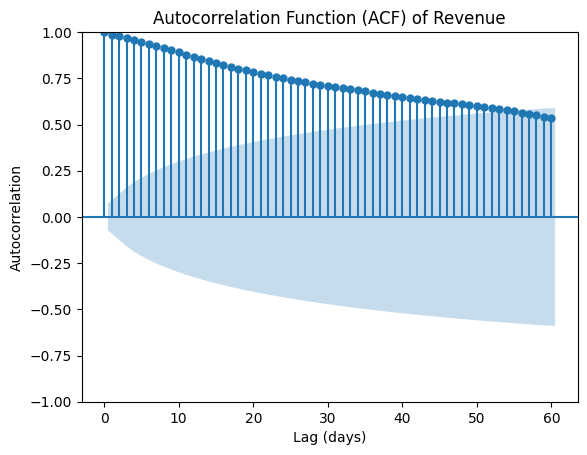

In [18]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,6))
plot_acf(df['Revenue'].dropna(), lags=60)
plt.title("Autocorrelation Function (ACF) of Revenue")
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.show()

In [19]:
#The ACF shows high autocorrelation at lag 1 indicating a trend
#There is a slow and smooth decay afterwards, meaning the data is non-stantionary (upward trend from earlier)
#No spikes at specific cutoffs, meaning likely no seasonality

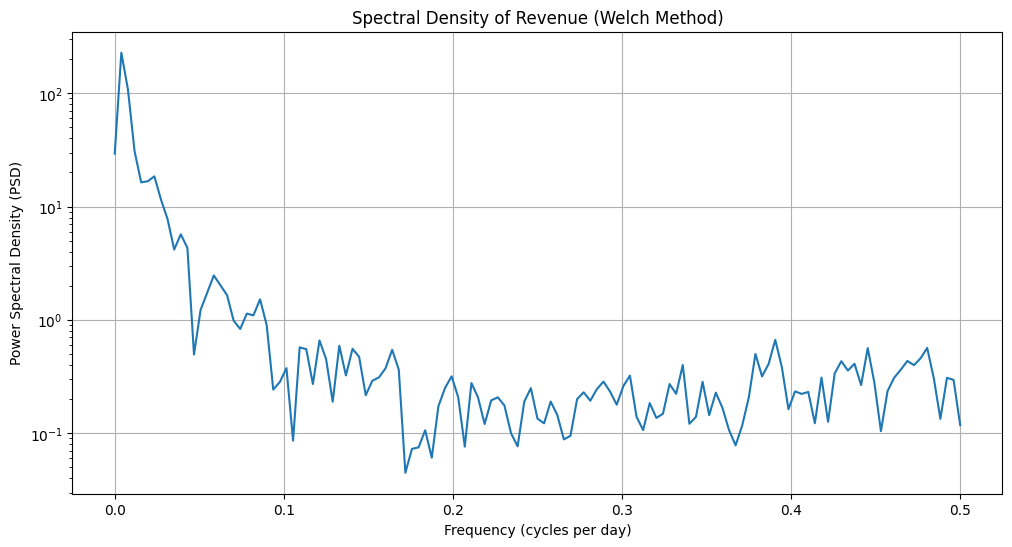

In [20]:
#Spectral density
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

y = df['Revenue'].dropna().values

#Welch Method
freqs, psd = welch(y, fs=1, nperseg=256)

plt.figure(figsize=(12,6))
plt.semilogy(freqs, psd) 
plt.title("Spectral Density of Revenue (Welch Method)")
plt.xlabel("Frequency (cycles per day)")
plt.ylabel("Power Spectral Density (PSD)")
plt.grid(True)
plt.show()

In [21]:
#Graph has a strong power at frequency 0, meaning a strong trend
#Drops off sharply afterwards, meaning there is no periodic behavior
#No spikes are present, meaning no seasonality

C:\Users\weepo\AppData\Local\Temp\ipykernel_70088\633101758.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


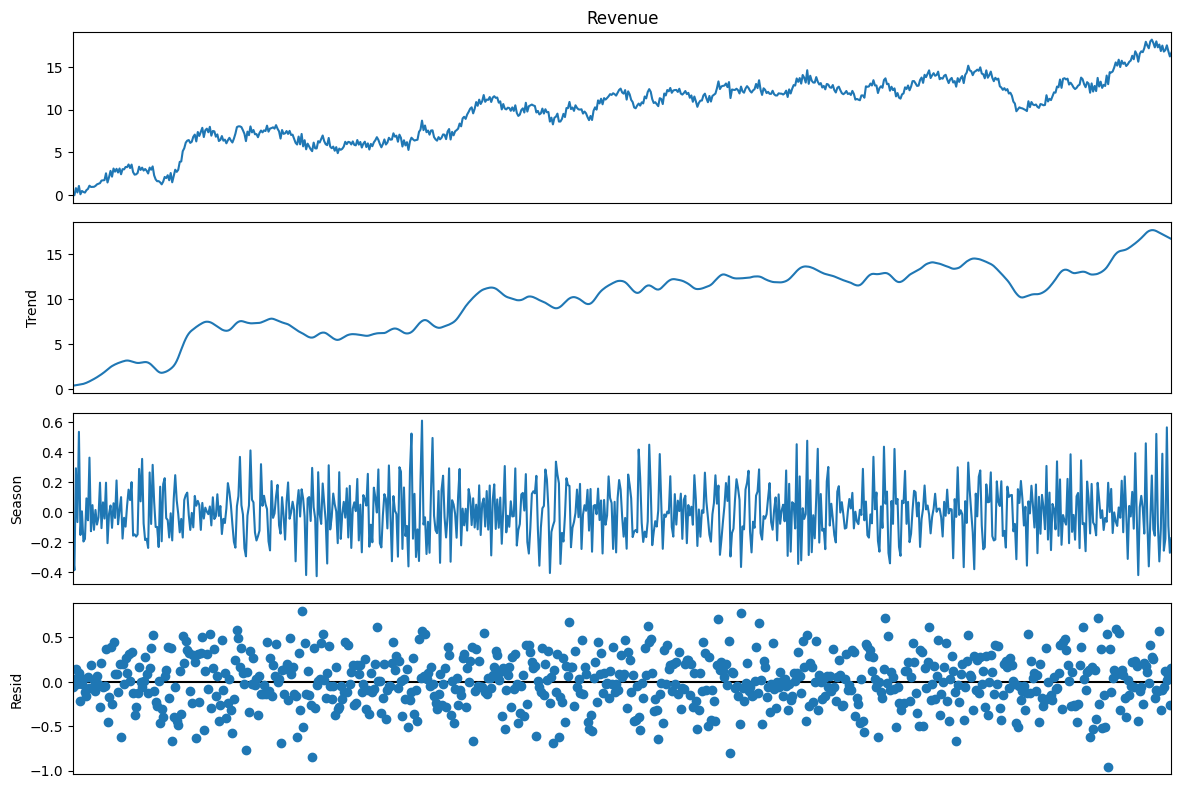

In [22]:
#Decomposed Time Series
from statsmodels.tsa.seasonal import STL

df['Day'] = pd.to_datetime(df['Day'])
df = df.set_index('Day')

stl = STL(df['Revenue'], period=7).fit()

fig = stl.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [23]:
#Original series shows the upward trend from earlier
#Trend line shows the same increase over time
#Seasonal component shows a non-periodic, low magnitude line, meaning no seasonality

#Residual Component:
#Even fluctuation around 0
#No drift up or down
#No stretches of + or - values
#Constant variance
#Just seems like random noise.

In [24]:
#Forecast using earlier ARIMA model: (1,1,0)
n_periods = 15
forecast, conf_int = stepwise_fit.predict(n_periods=n_periods, return_conf_int=True)

# Build a forecast index
forecast_index = pd.date_range(df.index[-1] + pd.Timedelta(days=1),
                               periods=n_periods, freq='D')

# Put into a DataFrame
forecast_df = pd.DataFrame({
    'Forecast': forecast,
    'Lower CI': conf_int[:, 0],
    'Upper CI': conf_int[:, 1]
}, index=forecast_index)

print(forecast_df)

                               Forecast   Lower CI   Upper CI
1970-01-02 00:00:00.000000731       NaN  15.528164  17.380070
1970-01-03 00:00:00.000000731       NaN  15.517229  17.613830
1970-01-04 00:00:00.000000731       NaN  15.288505  17.804401
1970-01-05 00:00:00.000000731       NaN  15.195031  17.982180
1970-01-06 00:00:00.000000731       NaN  15.066607  18.137449
1970-01-07 00:00:00.000000731       NaN  14.971742  18.286120
1970-01-08 00:00:00.000000731       NaN  14.875402  18.423616
1970-01-09 00:00:00.000000731       NaN  14.790827  18.555283
1970-01-10 00:00:00.000000731       NaN  14.710050  18.680366
1970-01-11 00:00:00.000000731       NaN  14.635316  18.800713
1970-01-12 00:00:00.000000731       NaN  14.564505  18.916524
1970-01-13 00:00:00.000000731       NaN  14.497740  19.028577
1970-01-14 00:00:00.000000731       NaN  14.434277  19.137193
1970-01-15 00:00:00.000000731       NaN  14.373897  19.242789
1970-01-16 00:00:00.000000731       NaN  14.316233  19.345638


In [25]:
#Results are from 1970 because dates weren't assigned, so just treat them as days since start

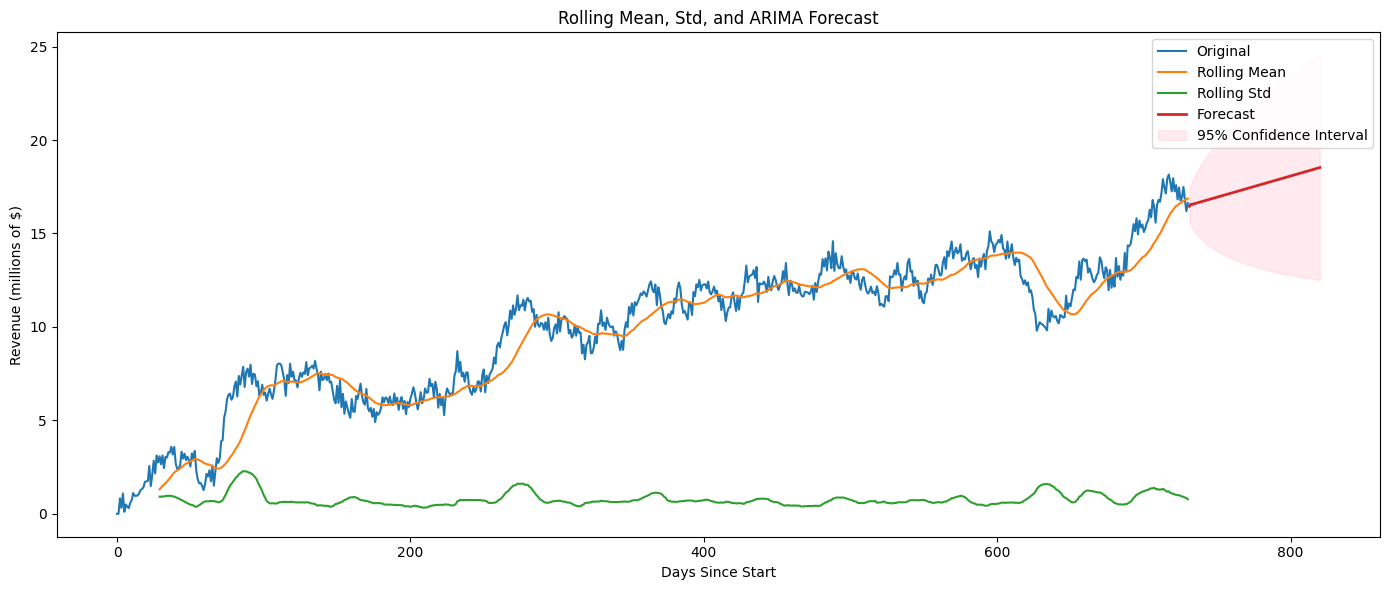

In [26]:
#Overlaying forecast onto earlier graph:
#Original rolling statistics
rolling_mean = df['Revenue'].rolling(window=30).mean()
rolling_std  = df['Revenue'].rolling(window=30).std()

#Generate ARIMA forecast
n_periods = 90
forecast, conf_int = stepwise_fit.predict(n_periods=n_periods, return_conf_int=True)

#x values (days since start) for historical data
x_hist = np.arange(len(df))  # 0, 1, 2, ..., N-1

#x values for forecast (continue right after history)
x_fore = np.arange(len(df), len(df) + n_periods)  # N, N+1, ..., N+29

#Plot
plt.figure(figsize=(14, 6))

#Historical series
plt.plot(x_hist, df['Revenue'].values, label='Original', color='tab:blue')

# olling mean & std (same x_hist)
plt.plot(x_hist, rolling_mean.values, label='Rolling Mean', color='tab:orange')
plt.plot(x_hist, rolling_std.values,  label='Rolling Std',  color='tab:green')

# Forecast line
plt.plot(x_fore, forecast, label='Forecast', color='tab:red', linewidth=2)

#Confidence interval shading
plt.fill_between(x_fore,
                 conf_int[:, 0],
                 conf_int[:, 1],
                 alpha=0.3, color='pink', label='95% Confidence Interval')

plt.title("Rolling Mean, Std, and ARIMA Forecast")
plt.xlabel("Days Since Start")
plt.ylabel("Revenue (millions of $)")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error

actual = df['Revenue'].iloc[-len(forecast):]

rmse = np.sqrt(mean_squared_error(actual, forecast))
print("RMSE:", rmse)

RMSE: 3.663145100919095


In [28]:
df['Revenue'].describe()

count    731.000000
mean       9.822901
std        3.852645
min        0.000000
25%        6.872836
50%       10.785571
75%       12.566911
max       18.154769
Name: Revenue, dtype: float64